Nate Lapin, Brya Patterson

MSIM, University of Washington

IMT575: Data Science III: Scaling, Applications, And Ethics

Dr. Ying Lin 

07-17-2025


# Introduction
The National Basketball Association (NBA) Draft Combine, held annually in May, is a mandatory multi-day showcase for draft-eligible players. Invited athletes undergo measurements, medical tests, interviews, athletic drills, and five-on-five games before NBA personnel, influencing their draft prospects and careers (NBA draft combine, 2025).

The goal of this project is to understand whether a player’s NBA Draft Combine performance metrics can predict whether they get drafted or not. This project builds upon ongoing work developed by Nate Lapin. A dataset was compiled and includes every NBA Draft Combine participant from 2000 through the 2025 draft class (Lapin, 2025). It includes basic measurements like height, weight, and wingspan, as well as athletic performance numbers like vertical jumps, sprint time, agility, and bench press reps.

We aim to look at the data to understand if there are clear differences between drafted and undrafted player metrics. We also want to develop and train a neural network model that takes in a player’s Combine stats and predicts whether they will be drafted. Ultimately, the model should be able to predict the player’s draft status by looking at Combine numbers.

**Project Question:** Can NBA Draft Combine performance metrics alone predict whether a player will be drafted?

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Data Exploration

The following section will look at the fetaures and trends within the data. This preliminary analysis is exploartory and looks to further understand the data and metrics.

In [4]:
# load data
nbaCombine_data = pd.read_csv('nba_combine_data.csv')
nbaCombine_data.head()
# nbaCombine_data.shape # (1678, 12)

,uniqueID,Year,"Player Name (Last Name, First Name)",Position,Height in Ft & In,Weight in lbs,Standing vertical Jump,Maximum Vertical Jump (with steps),three-quarter court sprint,lane agility drill,Bench Press test,Drafted?
0,1,2025,"Almansa, Izan",C,"6'9""",220.4,28.0,34.0,3.3,11.5,NaN,No
1,2,2025,"Avdalas, Neoklis",SF,"6'8""",197.8,27.0,33.5,3.2,11.0,NaN,No
2,3,2025,"Bailey, Ace",SF-PF,"6'8""",203.0,28.0,35.0,3.0,11.0,NaN,Yes
3,4,2025,"Bates, Tamar",SG,"6'4""",191.0,28.0,34.0,3.0,11.0,NaN,No
4,5,2025,"Brea, Koby",SG,"6'6""",202.0,28.0,34.0,3.0,11.0,NaN,Yes


In [5]:
# check for missing/nan values
data_all_missing = nbaCombine_data.isna().sum()
print(data_all_missing)

# uniqueID                                 0
# Year                                     0
# Player Name (Last Name, First Name)      0
# Position                                 1
# Height in Ft & In                        4
# Weight in lbs                            5
# Standing vertical Jump                 189
# Maximum Vertical Jump (with steps)     189
# three-quarter court sprint             197
# lane agility drill                     198
# Bench Press test                       604
# Drafted?                                 0
# Height_Inches                            4

uniqueID                                 0
Year                                     0
Player Name (Last Name, First Name)      0
Position                                 1
Height in Ft & In                        4
Weight in lbs                            5
Standing vertical Jump                 189
Maximum Vertical Jump (with steps)     189
three-quarter court sprint             197
lane agility drill                     198
Bench Press test                       604
Drafted?                                 0
dtype: int64


In [6]:
# create a copy for data cleaning
nbaCombine_cleaned = nbaCombine_data.copy()


In [7]:
# drop all rows with null/nan values
nbaCombine_cleaned = nbaCombine_data.dropna()
# nbaCombine_cleaned.shape # (1020, 12)
nbaCombine_cleaned.head()

,uniqueID,Year,"Player Name (Last Name, First Name)",Position,Height in Ft & In,Weight in lbs,Standing vertical Jump,Maximum Vertical Jump (with steps),three-quarter court sprint,lane agility drill,Bench Press test,Drafted?
369,370,2019,"Bazley, Darius",PF,"6'8""",208.4,30.5,37.0,3.27,11.09,4.0,Yes
371,372,2019,"Bone, Jordan",SG,"6'2""",179.0,36.0,42.5,3.08,9.97,7.0,Yes
372,373,2019,"Bowen II, Brian",SF,"6'6""",200.0,32.0,35.5,3.26,10.98,1.0,No
373,374,2019,"Bowman, Ky",PG,"6'1""",181.2,27.5,33.0,3.26,11.11,4.0,No
374,375,2019,"Brazdeikis, Ignas",SF,"6'6""",220.8,31.0,36.5,3.36,11.06,13.0,Yes


In [8]:
# convert height to inches for easier analysis
def height_to_inches(height_str):
    try:
        feet, inches = map(int, height_str.replace('"', '').split("'"))
        return feet * 12 + inches
    except:
        return None

nbaCombine_cleaned['Height_Inches'] = nbaCombine_cleaned['Height in Ft & In'].apply(height_to_inches)
# nbaCombine_cleaned['Height in Ft & In'].head() # 6'8"
nbaCombine_cleaned['Height_Inches'].head() # 80

/var/folders/fq/09gsw5bd73x2sk4svcrxcw140000gn/T/ipykernel_35619/3796797565.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nbaCombine_cleaned['Height_Inches'] = nbaCombine_cleaned['Height in Ft & In'].apply(height_to_inches)


369    80
371    74
372    78
373    73
374    78
Name: Height_Inches, dtype: int64

In [9]:
# check if 'Drafted?' is str or bool
print(nbaCombine_cleaned['Drafted?'].unique()) # ['No' 'Yes']

['Yes' 'No']


In [10]:
# convert 'Drafted?' to bool

def convert_to_boolean(value):
    if isinstance(value, bool):
        return value
    if isinstance(value, (int, float)):
        return bool(value)
    if isinstance(value, str):
        return value.lower() in ['true', 'yes', '1', 't', 'y']
    return None

nbaCombine_cleaned['Drafted?'] = nbaCombine_cleaned['Drafted?'].apply(convert_to_boolean)
nbaCombine_cleaned['Drafted?'].head()

/var/folders/fq/09gsw5bd73x2sk4svcrxcw140000gn/T/ipykernel_35619/2085504939.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nbaCombine_cleaned['Drafted?'] = nbaCombine_cleaned['Drafted?'].apply(convert_to_boolean)


369     True
371     True
372    False
373    False
374     True
Name: Drafted?, dtype: bool

## Draft Rate Trend
Shows how the percentage of players getting drafted has changed over time.

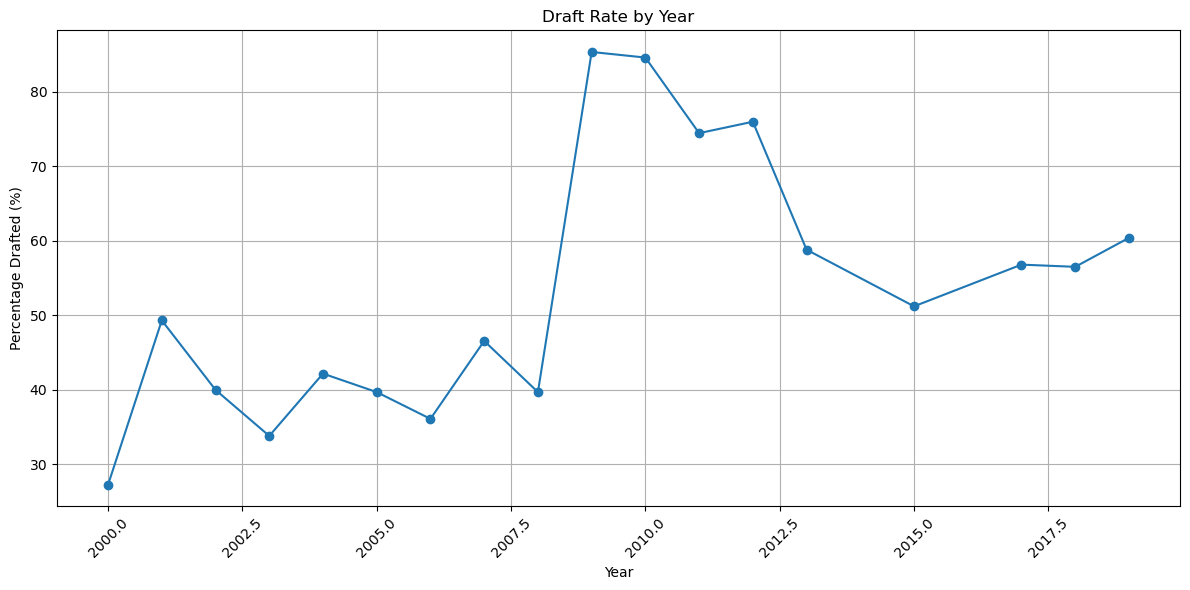

In [12]:
# draft Rate Over Years
plt.figure(figsize=(12, 6))
yearly_draft_rate = nbaCombine_cleaned.groupby('Year')['Drafted?'].mean() * 100
plt.plot(yearly_draft_rate.index, yearly_draft_rate.values, marker='o')
plt.title('Draft Rate by Year')
plt.xlabel('Year')
plt.ylabel('Percentage Drafted (%)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
# plt.savefig('draft_rate_trend.png')
# plt.close()


This chart shows the "Draft Rate by Year" from 2000 to 2017, displaying the percentage of NBA Combine participants who were drafted each year.

Overall, the draft rate has shown significant variability over the years. There is a notable increase in draft rate from 2000 to 2010. After 2010, the rate has generally stabilized at a higher level compared to the early 2000s.

We can see that in 2000, around 25-30% of eligible players were drafted. During its peak around 2009-2010, approximately 80% of players were drafted. More recently, from 2015-2017 drafts stabilized around 55-60%. 


To further contextualize the results of this analysis, the following data shows the yearly count of drafted and undrafted players:

In [15]:
# create a count of drafted/undrafted players by year
draft_counts = pd.crosstab(nbaCombine_cleaned['Year'], nbaCombine_cleaned['Drafted?'])

# rename columns for better clarity
draft_counts.columns = ['Not Drafted', 'Drafted']

# print the actual numbers
print("\nYearly counts of drafted and undrafted players:")
print(draft_counts)

# print total numbers
print("\nTotal numbers:")
print("Total players:", len(nbaCombine_cleaned))
print("Total drafted:", nbaCombine_cleaned['Drafted?'].sum())
print("Total not drafted:", len(nbaCombine_cleaned) - nbaCombine_cleaned['Drafted?'].sum())
print("\nOverall draft rate: {:.2f}%".format(nbaCombine_cleaned['Drafted?'].mean() * 100))


Yearly counts of drafted and undrafted players:
      Not Drafted  Drafted
Year                      
2000           40       15
2001           38       37
2002           42       28
2003           45       23
2004           37       27
2005           41       27
2006           46       26
2007           39       34
2008           41       27
2009            6       35
2010            6       33
2011           12       35
2012           12       38
2013           21       30
2015           20       21
2017           19       25
2018           20       26
2019           19       29

Total numbers:
Total players: 1020
Total drafted: 516
Total not drafted: 504

Overall draft rate: 50.59%


From this we can see that there is large variation in the sample sizes across years. That is, the number of participants in the Combine year to year was consistent in 2000-2008 with approximately 65-80+ total participants per year. 2009-2012 had dramatically fewer total participants (41, 39, 47, and 50 players respectively). Finally, 2013-2019 stabilized at around 40-50 participants per year.

The peak around 2009-2010 (reaching ~80%) had very few total participants (only 41 and 39 players), and of these small groups, 35 (85%) and 33 (84%) were drafted respectively. This could suggest that the combine might have been more exclusive during these years, possibly only inviting highly-rated prospects.

The total numbers show remarkable overall balance with 516 drafted versus 504 not drafted. This is an overall draft rate of 50.59%, suggesting that, historically, attending the Combine gives a prospect roughly a 50-50 chance of being drafted.

Both representations of the data shows that the Combine has become a more reliable pathway to being drafted over time. Higher draft rates in recent years, compared to those in the early 2000s, suggest that teams are putting more stock in Combine performance and the event itself is likely attracting more draft-worthy players. There is also the possibility that the selection process for the Combine has changed or improved so that the opportunities to be drafted are higher than the early 2000s, but not as high as its peak in 2009-2010.


## Position Distribution
Displays the draft rate for different positions, helping understand which positions are more likely to get drafted.

These are abbreviations for basketball player positions:
- PG: Point Guard
- SG: Shooting Guard
- SF: Small Forward
- PF: Power Forward
- C: Center

The hyphenated terms indicate a player who can play effectively at both positions:
- SF-PF: Small Forward-Power Forward (a player who can play either small forward or power forward)
- SG-SF: Shooting Guard-Small Forward
- PG-SG: Point Guard-Shooting Guard
- SG-PG: Shooting Guard-Point Guard
- SF-SG: Small Forward-Shooting Guard
- PF-C: Power Forward-Center
- C-PF: Center-Power Forward
- PF-SF: Power Forward-Small Forward

In [18]:
# check unique 'Position'
print(nbaCombine_cleaned['Position'].unique()) 
# ['C' 'SF' 'SF-PF' 'SG' 'PG-SG' 'PF' 'PG' 'SG-SF' 'SF-SG' 'PF-C' 'SG-PG'
# 'C-PF' 'PF-SF']

['PF' 'SG' 'SF' 'PG' 'SF-PF' 'C' 'SG-SF' 'PG-SG' 'SG-PG' 'SF-SG' 'PF-C'
 'C-PF' 'PF-SF']


<Figure size 1200x600 with 0 Axes>

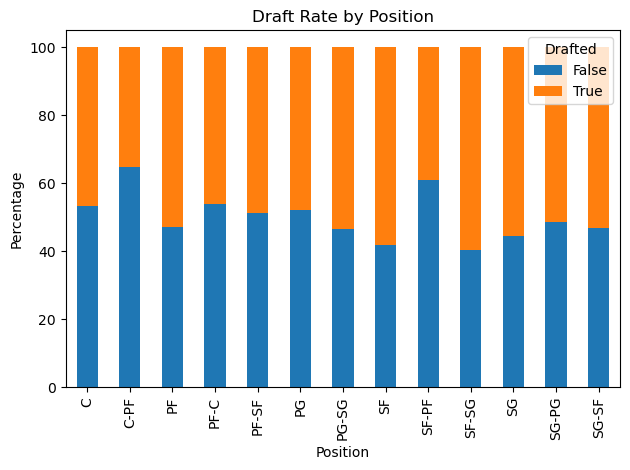

In [19]:
# Position Distribution - Drafted vs Undrafted
plt.figure(figsize=(12, 6))
position_draft = pd.crosstab(nbaCombine_cleaned['Position'], nbaCombine_cleaned['Drafted?'], normalize='index') * 100
position_draft.plot(kind='bar', stacked=True)
plt.title('Draft Rate by Position')
plt.xlabel('Position')
plt.ylabel('Percentage')
plt.legend(title='Drafted')
plt.tight_layout()
# plt.savefig('position_draft_rate.png')
# plt.close()


In [20]:
# Print some summary statistics
print("\nDraft Rate by Position:")
print(position_draft.round(2))


Draft Rate by Position:
Drafted?  False  True 
Position              
C         53.23  46.77
C-PF      64.91  35.09
PF        47.06  52.94
PF-C      53.97  46.03
PF-SF     51.11  48.89
PG        52.15  47.85
PG-SG     46.67  53.33
SF        41.90  58.10
SF-PF     60.87  39.13
SF-SG     40.48  59.52
SG        44.54  55.46
SG-PG     48.65  51.35
SG-SF     46.97  53.03


This visualization shows the draft rates broken down by player position.

Most positions show roughly a 40-60% split between drafted (True) and undrafted (False)
Notably:
- SF (Small Forward) appears to have the highest draft rate (~60% drafted), 
- C/PF-C (Centers and Power Forward-Centers) show slightly lower draft rates (~45-50% drafted)
- PG-SG (Point Guard-Shooting Guard combo) shows one of the more balanced distributions
There also some notable differences in the “pure” versus “hybrid” positions.

Pure positions show draft rates of:
- Centers (C): ~45% draft rate
- Power Forwards (PF): ~55% draft rate
- Small Forwards (SF): ~60% draft rate
- Shooting Guards (SG): ~55% draft rate
- Point Guards (PG): ~52% draft rate

While hybrid positions generally show similar rates to pure positions. Most hybrid positions maintain draft rates between 45-55%. This suggests versatility neither significantly helps nor hurts draft chances.

Overall, the data shows that Small Forwards have a slight advantage in draft probability, while Centers might face slightly tougher competition or higher standards. Hybrid positions are valued similarly to pure positions, but no position shows dramatically better or worse draft prospects (all within ~15% range). The ability to play multiple positions (hybrid designations) doesn't seem to significantly impact draft chances. 


## Athletic Metrics Comparison
Box plots comparing each athletic measurement between drafted and undrafted players, showing the distribution and potential differences.


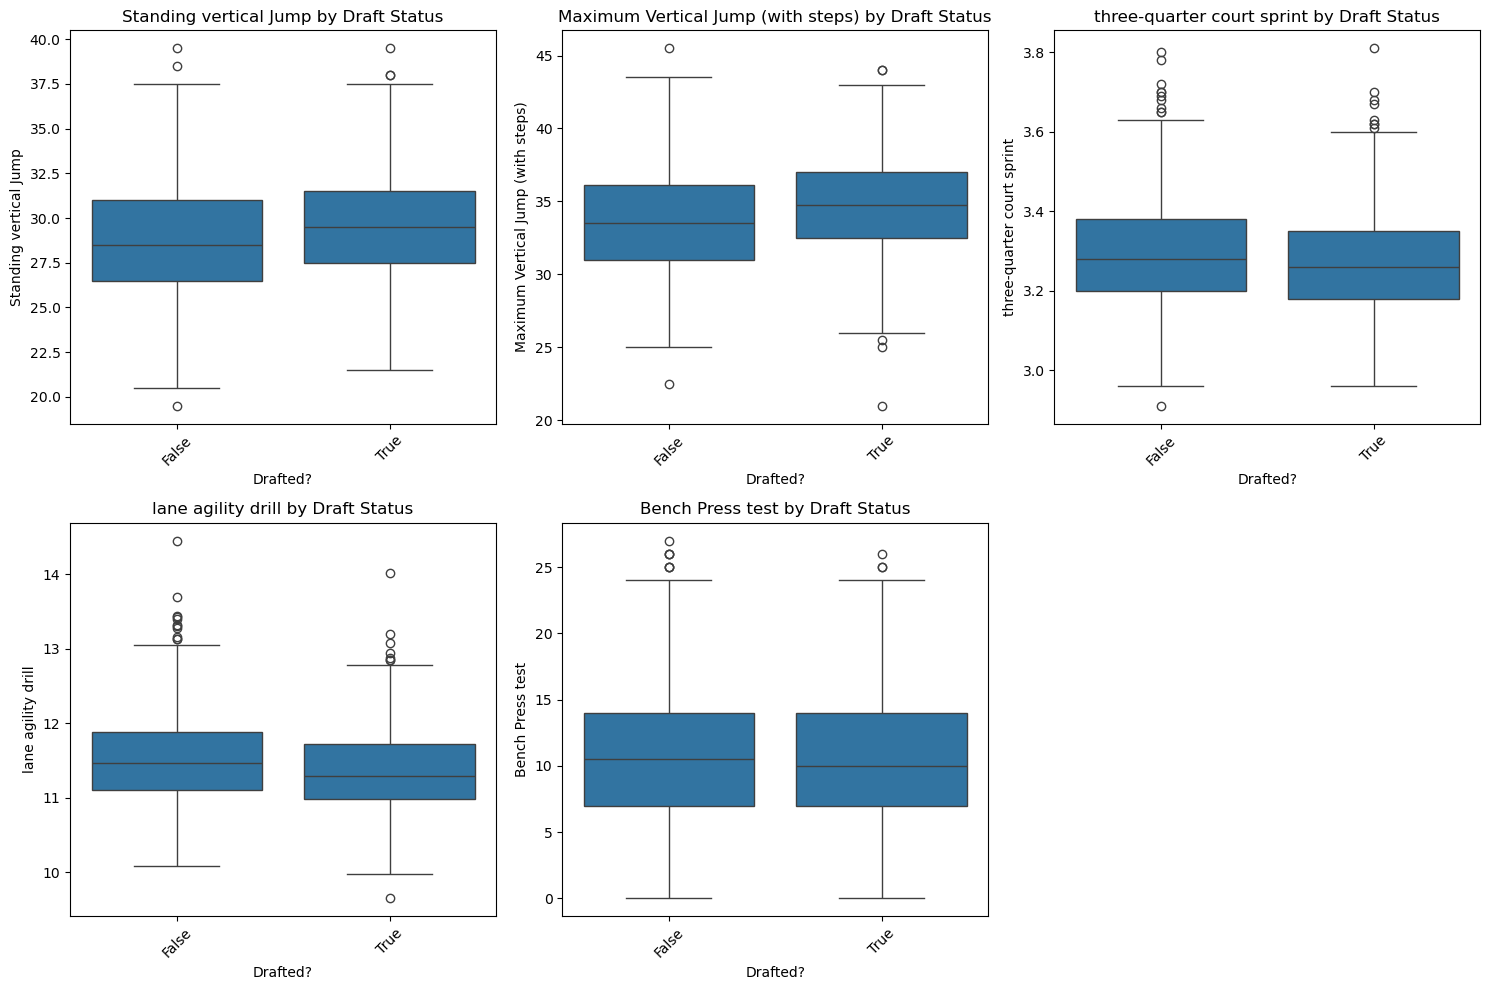

In [23]:
# Athletic Metrics Box Plots
athletic_metrics = ['Standing vertical Jump', 'Maximum Vertical Jump (with steps)', 
                   'three-quarter court sprint', 'lane agility drill', 'Bench Press test']

plt.figure(figsize=(15, 10))
for i, metric in enumerate(athletic_metrics, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='Drafted?', y=metric, data=nbaCombine_cleaned)
    plt.title(f'{metric} by Draft Status')
    plt.xticks(rotation=45)
plt.tight_layout()
# plt.savefig('athletic_metrics_comparison.png')
# plt.close()



In [24]:
print("\nAthletic Metrics - Drafted vs Undrafted (Mean Values):")
print(nbaCombine_cleaned.groupby('Drafted?')[athletic_metrics].mean().round(2))


Athletic Metrics - Drafted vs Undrafted (Mean Values):
          Standing vertical Jump  Maximum Vertical Jump (with steps)  \
Drafted?                                                               
False                      28.64                               33.63   
True                       29.52                               34.76   

          three-quarter court sprint  lane agility drill  Bench Press test  
Drafted?                                                                    
False                           3.30               11.54             10.47  
True                            3.27               11.36             10.39  


This visualization presents a comparative analysis of five NBA Combine metrics between drafted and undrafted players using box plots. The analysis reveals that drafted players generally exhibit slightly better performance across most metrics, though the differences are often subtle rather than dramatic, with significant overlap between the two groups.

Specifically, the Maximum Vertical Jump and Three-quarter Court Sprint appear to be the most discriminating metrics, with drafted players showing a more noticeable edge. The Standing Vertical Jump also shows a slight advantage for drafted players.

Conversely, the Bench Press Test and Lane Agility Drill are identified as the least discriminating. For these metrics, the performance distributions between drafted and undrafted players are almost identical, suggesting they are poor predictors of draft status.

In summary, while drafted players tend to outperform undrafted players marginally in several athletic tests, the overall patterns indicate that combine metrics alone are not strong, singular predictors of whether a player will be drafted. The distinctions are subtle, and significant performance overlap exists across all evaluated tests.

## Height-Weight Distribution
A scatter plot showing the relationship between height and weight, colored by draft status and marked by position.


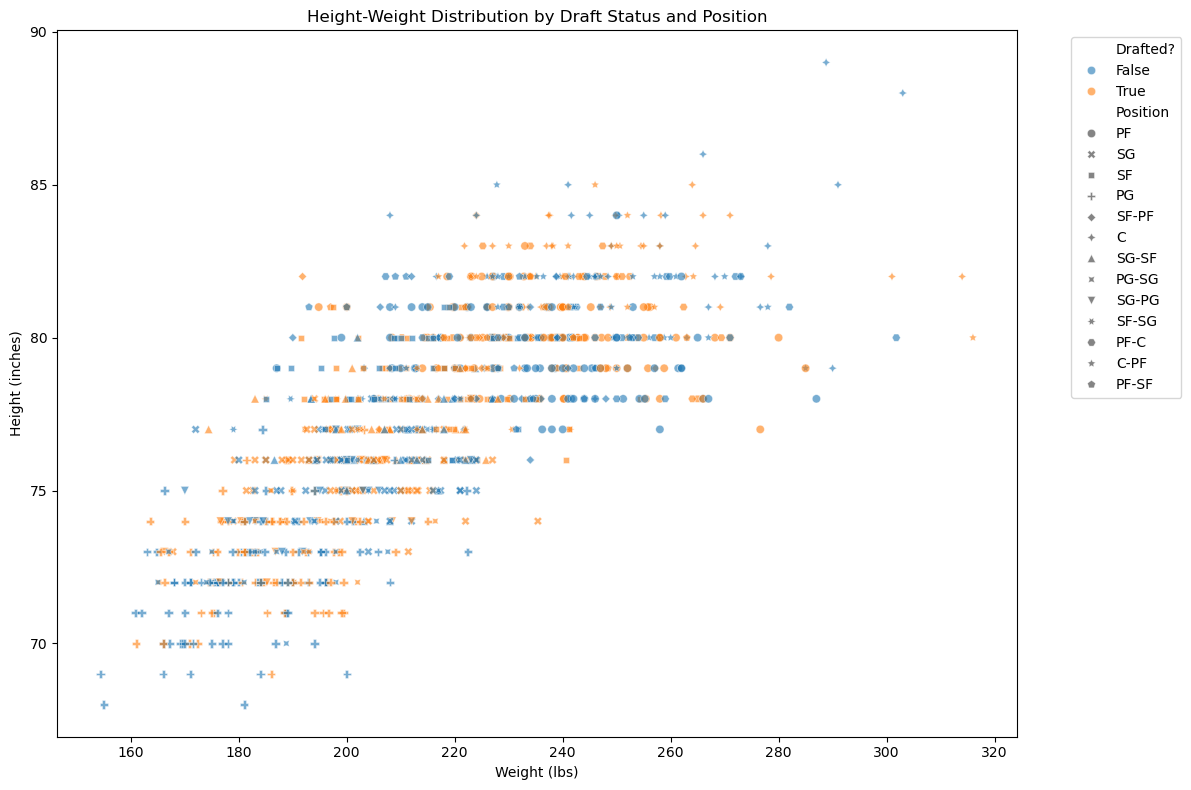

In [27]:
# Height-Weight Distribution
plt.figure(figsize=(12, 8))
sns.scatterplot(data=nbaCombine_cleaned, x='Weight in lbs', y='Height_Inches', 
                hue='Drafted?', style='Position', alpha=0.6)
plt.title('Height-Weight Distribution by Draft Status and Position')
plt.xlabel('Weight (lbs)')
plt.ylabel('Height (inches)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
# plt.savefig('height_weight_distribution.png')
# plt.close()



This scatter plot shows the relationship between height (in inches) and weight (in lbs) for NBA Combine participants, with points colored by draft status (True/False) and marked by position.

It highlights a strong correlation between a player's height and weight and their basketball position, with clear clusters emerging. Guards tend to be the shortest and lightest, primarily ranging from 70-75 inches tall and 160-200 lbs. Wings occupy a middle ground, typically 75-80 inches tall and 180-230 lbs, while Bigs are the tallest and heaviest, generally found at 80-85+ inches and 220-300 lbs. This stratification is evident across the entire range of observed player sizes, from approximately 5'10" to 7'6" in height and 160-320 lbs in weight.

Beyond positional clustering, the analysis also reveals patterns related to draft status. While draft outcomes for Guards appear mixed across their size range, there's a noticeable preference for drafted Wings who fall within an "ideal" size. For Bigs, being drafted seems more probable if they are within a specific "sweet spot" of height-weight ratio for their position. This suggests that while athleticism is important, fitting a traditional physical mold for a given position can influence a player's draft prospects.

Each position has identified "sweet spots" for optimal height and weight: Point Guards are typically 72-75 inches and 170-190 lbs; Shooting Guards 74-77 inches and 180-200 lbs; Small Forwards 77-80 inches and 200-225 lbs; Power Forwards 80-83 inches and 220-250 lbs; and Centers 82-85 inches and 240-280 lbs. These ranges represent the traditional and most common physical profiles for successful players at each role.

A key takeaway is that very few successful outliers exist at the extreme ends of the height and weight spectrum. The majority of drafted players fall within these established traditional positional size ranges, indicating an "ideal" height-weight ratio for each role. Hybrid positions, such as SF-PF, often bridge the physical gaps between their traditional counterparts.

Ultimately, these physical patterns have significant draft implications. Players who fit within these traditional positional size ranges are more likely to be drafted. Conversely, extreme outliers—whether unusually light or heavy for their height—are less commonly drafted. This suggests that while individual skill is paramount, physical archetype plays a substantial role in a player's draftability, and positional versatility might also be influenced by how a player's physical profile aligns with these established distributions.

In [29]:
# create height and weight bins
height_bins = np.arange(65, 95, 3) # 3-inch intervals
weight_bins = np.arange(150, 350, 20) # 20-pound intervals

# create height and weight categories using .loc
nbaCombine_cleaned.loc[:, 'Height_Category'] = pd.cut(nbaCombine_cleaned['Height_Inches'], bins=height_bins)
nbaCombine_cleaned.loc[:, 'Weight_Category'] = pd.cut(nbaCombine_cleaned['Weight in lbs'], bins=weight_bins)

/var/folders/fq/09gsw5bd73x2sk4svcrxcw140000gn/T/ipykernel_35619/309097905.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nbaCombine_cleaned.loc[:, 'Height_Category'] = pd.cut(nbaCombine_cleaned['Height_Inches'], bins=height_bins)
/var/folders/fq/09gsw5bd73x2sk4svcrxcw140000gn/T/ipykernel_35619/309097905.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nbaCombine_cleaned.loc[:, 'Weight_Category'] = pd.cut(nbaCombine_cleaned['Weight in lbs'], bins=weight_bins)


In [30]:
# calculate success rates for each height-weight combination
success_rates = nbaCombine_cleaned.groupby(['Height_Category', 'Weight_Category'], observed=True).agg({
    'Drafted?': ['count', 'mean'],
    'Position': lambda x: ', '.join(sorted(set(x)))
}).round(3)

# create a pivot table for the heatmap
pivot_table = nbaCombine_cleaned.pivot_table(
    values='Drafted?',
    index='Height_Category',
    columns='Weight_Category',
    aggfunc=['mean', 'count'],
    observed=True  # Add observed=True here
)

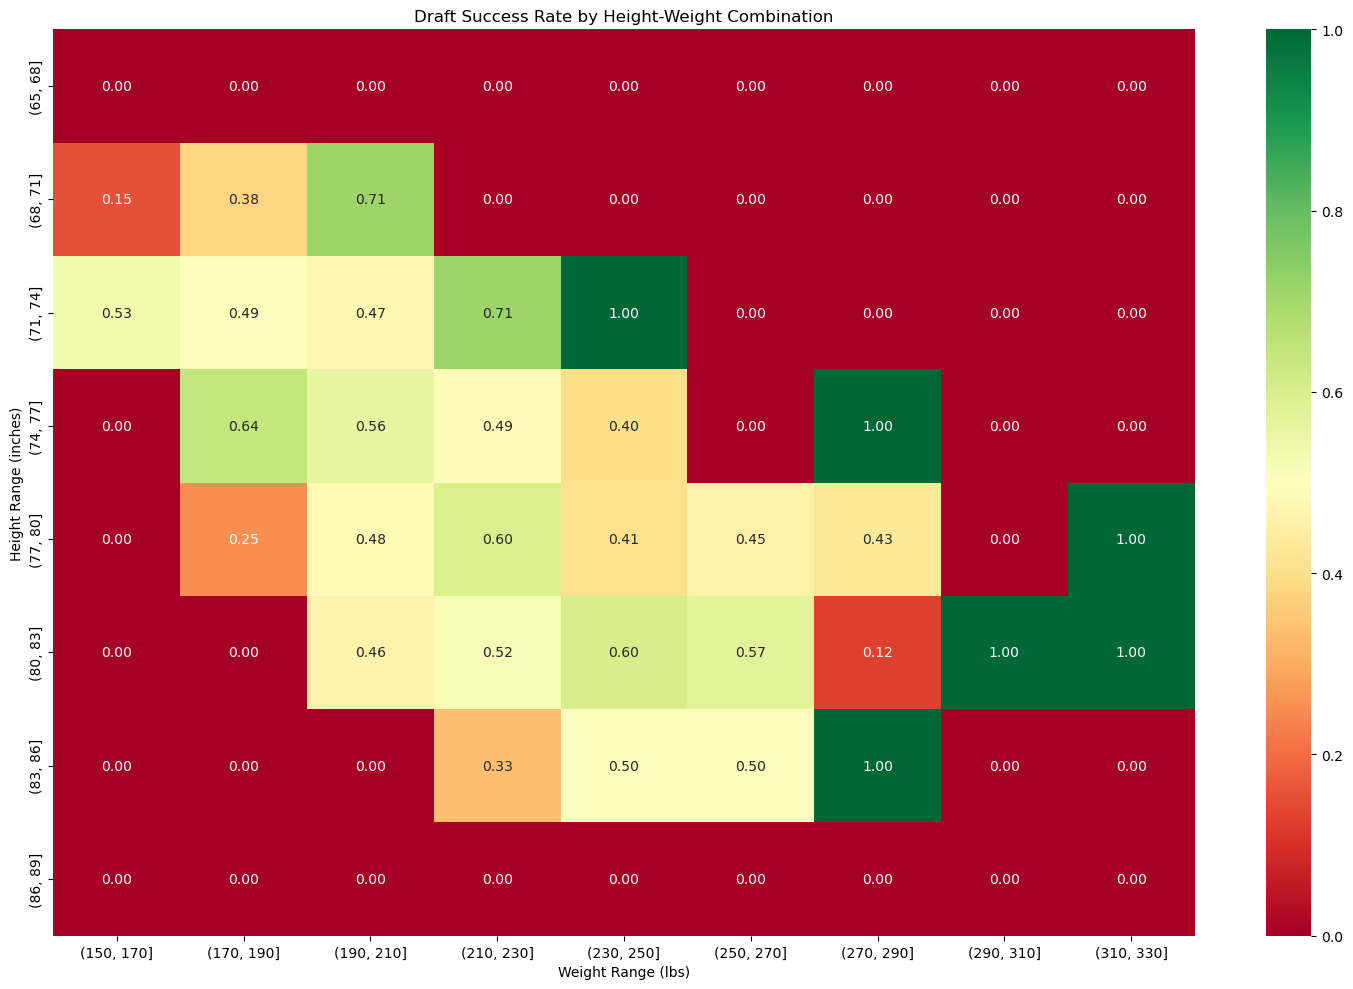

In [31]:
# Plot the heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(pivot_table['mean'].fillna(0),
annot=True,
fmt='.2f',
cmap='RdYlGn',
center=0.5)
plt.title('Draft Success Rate by Height-Weight Combination')
plt.xlabel('Weight Range (lbs)')
plt.ylabel('Height Range (inches)')
plt.tight_layout()
# plt.savefig('height_weight_success_rates.png')
# plt.close()

In [32]:
# Print detailed analysis
print("\nSuccess Rates by Height-Weight Combination:")
print("\nFormat: (Total Players, Draft Rate, Common Positions)")
for (height, weight), group in success_rates.iterrows():
    count = group[('Drafted?', 'count')]
if count >= 5: # Only show combinations with at least 5 players
    rate = group[('Drafted?', 'mean')] * 100
    positions = group[('Position', '<lambda>')]
    print(f"\nHeight: {height}")
    print(f"Weight: {weight}")
    print(f"Count: {count}")
    print(f"Draft Rate: {rate:.1f}%")
    print(f"Common Positions: {positions}")

# Additional summary statistics
print("\nOverall Summary:")
print(f"Total Players Analyzed: {len(nbaCombine_cleaned)}")
print(f"Overall Draft Rate: {(nbaCombine_cleaned['Drafted?'].mean() * 100):.1f}%")


Success Rates by Height-Weight Combination:

Format: (Total Players, Draft Rate, Common Positions)

Overall Summary:
Total Players Analyzed: 1020
Overall Draft Rate: 50.6%


For more context, we'll look at the success rates by height-weight combinations. The above heatmap shows draft success rates by height-weight combinations, where darker green indicates higher success rates and darker red indicates lower success rates. The overall draft rate is 50.6%, so is the baseline for comparison.

This analysis identifies specific height and weight combinations that correlate with varying success rates in the NBA draft, highlighting "sweet spots" and less favorable profiles. The highest success rates (100%) are observed in two distinct categories: players between 77-80 inches (6'5"-6'8") weighing 270-290 lbs, and those between 80-83 inches (6'8"-6'11") weighing 290-330 lbs. These represent the most optimal physical profiles for being drafted.

Beyond these ideal categories, above-average success rates (around 71%) are found for slightly shorter players. This includes individuals 68-71 inches (5'8"-5'11") weighing 190-210 lbs, and those 71-74 inches (5'11"-6'2") at 210-230 lbs. The majority of other height-weight combinations fall into an "average" success rate of 40-60%, which is consistent with the overall draft rate.

Conversely, poor success rates (indicated in red) are seen in several extreme categories. This includes very light players (under 170 lbs) across all heights, very heavy players (over 290 lbs) at shorter heights, and unusual height combinations paired with non-typical weights. These combinations generally represent less desirable physical profiles for NBA prospects.

In terms of position-specific insights, Guards (shorter heights) find the most success within the 190-230 lbs range, while Wings (middle heights) show consistent success across various weight ranges. Bigs (taller heights) benefit from heavier weights. Overall, the data reveals that optimal draft success rates align closely with traditional, position-specific body types. There's a clear diagonal pattern of increasing success from bottom-left (shorter/lighter) to top-right (taller/heavier), provided the weight is proportional to height. Extreme combinations of very light or very heavy for a given height consistently lead to lower success, underscoring the importance of a balanced and traditional physical profile for NBA draft prospects.

## Correlation Matrix
Shows how different athletic metrics are correlated with each other.

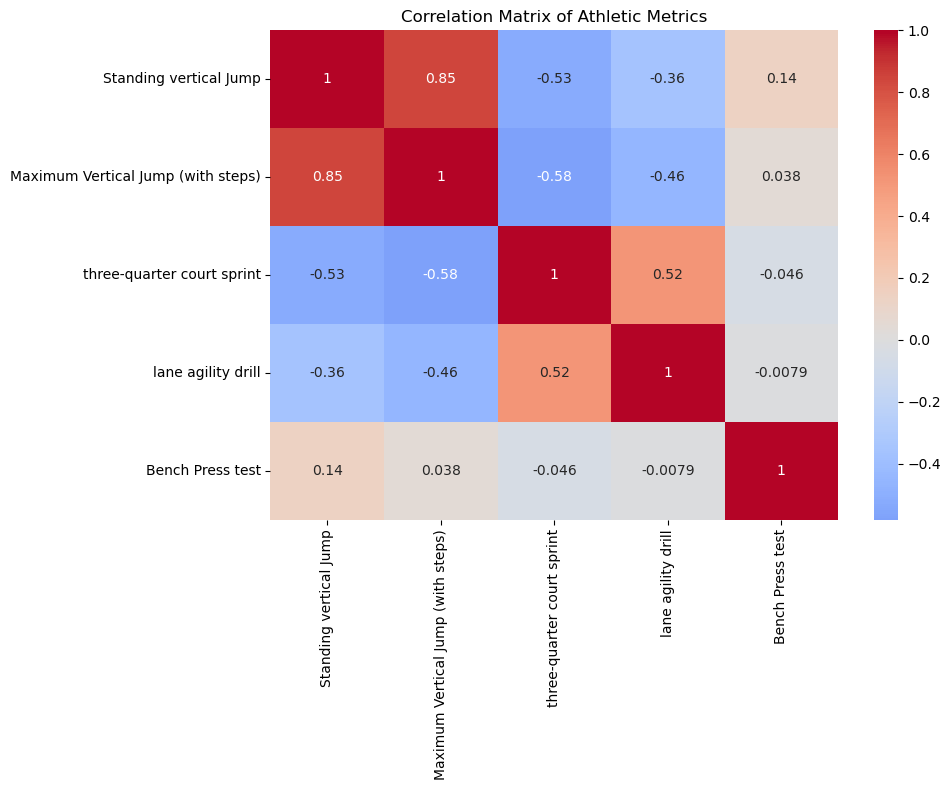

In [35]:
# Correlation Matrix of Athletic Metrics
athletic_metrics_corr = nbaCombine_cleaned[athletic_metrics].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(athletic_metrics_corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Athletic Metrics')
plt.tight_layout()
# plt.savefig('correlation_matrix.png')
# plt.close()

The matrix shows how different athletic measurements relate to each other, with values ranging from -1 (perfect negative correlation) to 1 (perfect positive correlation).

This analysis explores the correlations between various NBA Combine metrics, revealing insights into how different athletic abilities relate to each other. Unsurprisingly, a very strong positive correlation (0.85) exists between the Standing Vertical Jump and Maximum Vertical Jump. This indicates that players who perform well in one vertical leap test tend to excel in the other, suggesting a degree of redundancy between these two measures of explosive lower-body power.

Conversely, a moderate negative correlation is observed between Three-quarter Court Sprint and both vertical jumps (around -0.55). Since lower sprint times are better, this negative correlation implies that players with stronger vertical leaping ability also tend to be faster runners. Similarly, Lane Agility shows moderate negative correlations with vertical jumps (between -0.36 and -0.46), indicating a connection between agility and jumping, though not as strong as with straight-line speed.

A moderate positive correlation (0.52) is also noted between Lane Agility and Three-quarter Court Sprint, demonstrating that these two speed and agility metrics are related but measure distinct aspects of quickness. However, the Bench Press Test stands out for its very weak correlations with all other athletic metrics (ranging from -0.0079 to 0.14). This suggests that upper body strength, as measured by the bench press, is largely independent of a player's jumping ability, sprint speed, or agility.


In [37]:
# Calculate statistical significance
print("\nStatistical Significance (t-test p-values):")
for metric in athletic_metrics:
    drafted = nbaCombine_cleaned[nbaCombine_cleaned['Drafted?'] == True][metric].dropna()
    undrafted = nbaCombine_cleaned[nbaCombine_cleaned['Drafted?'] == False][metric].dropna()
    t_stat, p_val = stats.ttest_ind(drafted, undrafted)
    print(f"{metric}: p-value = {p_val:.4f}")


Statistical Significance (t-test p-values):
Standing vertical Jump: p-value = 0.0000
Maximum Vertical Jump (with steps): p-value = 0.0000
three-quarter court sprint: p-value = 0.0076
lane agility drill: p-value = 0.0000
Bench Press test: p-value = 0.8296


Regarding statistical significance, t-test p-values indicate that most combine metrics show a highly significant difference between drafted and undrafted players. The p-values for Standing Vertical Jump, Maximum Vertical Jump, and Lane Agility Drill are all 0.0000, while the Three-quarter Court Sprint has a p-value of 0.0076. This strong statistical significance suggests these metrics are relevant in distinguishing drafted from undrafted players. The notable exception is the Bench Press Test, with a high p-value of 0.8296, confirming its lack of significant predictive power regarding draft status.

In [39]:
plt.figure(figsize=(12, 6))
yearly_draft_rate = df.groupby('Year')['Drafted?'].mean() * 100
plt.plot(yearly_draft_rate.index, yearly_draft_rate.values, marker='o')
plt.title('Draft Rate by Year')
plt.xlabel('Year')
plt.ylabel('Percentage Drafted (%)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('draft_rate_trend.png')
plt.close()


NameError: name 'df' is not defined

<Figure size 1200x600 with 0 Axes>